In [1]:
from typing_extensions import TypedDict, Optional, Annotated, NotRequired

from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage

In [2]:
from langchain_mcp_adapters.client import MultiServerMCPClient
from langchain_mcp_adapters.tools import load_mcp_tools
from langchain_tavily import TavilySearch

    "stock_aggregator": ["health_check", "analyze_stock"],
    "allocation_agent": ["health_check", "get_allocation"],
    "portfolio_agent": ["health_check", "analyze_portfolio"],
    "portfolio_analysis_agent": ["health_check", "analyze_portfolio"],
    "diversification_agent": ["health_check", "analyze_portfolio"],
    "correlation_agent": ["health_check", "analyze_correlation"],
    "fundamental_documents_agent": [
        "health_check",
        "get_fundamental_report",
        "query_transcripts",
        "get_company_news",
        "swot_analysis",
    ],
    "memory_agent": ["health_check", "analyze_memory"],
    "explain_agent": ["health_check", "analyze_explain"],
    "qna_agent": ["health_check", "query_transcripts", "get_company_news"],
    "swot_agent": ["health_check", "swot_analysis"],
}

In [3]:
import os
import sys

_MCP_BASE = {
    "command": sys.executable,
    "transport": "stdio",
    "cwd": os.getcwd(),
}

stock_mcp_client = MultiServerMCPClient({
    "stock-based_analyser": {
        **_MCP_BASE,
        "args": ["apis/start_mcp_server.py", "stock_aggregator"],
    }
})

allocation_mcp_client = MultiServerMCPClient({
    "allocation-based_analyser": {
        **_MCP_BASE,
        "args": ["apis/start_mcp_server.py", "allocation_agent"],
    }
})

portfolio_mcp_client = MultiServerMCPClient({
    "portfolio-based_analyser": {
        **_MCP_BASE,
        "args": ["apis/start_mcp_server.py", "portfolio_agent"],
    }
})

correlation_mcp_client = MultiServerMCPClient({
    "correlation-based_analyser": {
        **_MCP_BASE,
        "args": ["apis/start_mcp_server.py", "correlation_agent"],
    }
})

fundamental_mcp_client = MultiServerMCPClient({
    "fundamental-based_analyser": {
        **_MCP_BASE,
        "args": ["apis/start_mcp_server.py", "fundamental_documents_agent"],
    }
})

memory_mcp_client = MultiServerMCPClient({
    "memory-based_analyser": {
        **_MCP_BASE,
        "args": ["apis/start_mcp_server.py", "memory_agent"],
    }
})

explainability_mcp_client = MultiServerMCPClient({
    "explainability-based_analyser": {
        **_MCP_BASE,
        "args": ["apis/start_mcp_server.py", "explain_agent"],
    }
})

qna_mcp_client = MultiServerMCPClient({
    "qna-based_analyser": {
        **_MCP_BASE,
        "args": ["apis/start_mcp_server.py", "qna_agent"],
    }
})

swot_mcp_client = MultiServerMCPClient({
    "swot-based_analyser": {
        **_MCP_BASE,
        "args": ["apis/start_mcp_server.py", "swot_agent"],
    }
})

In [4]:
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
import io
import ipykernel.iostream
import sys

# MCP stdio on Windows expects stderr.fileno(); Jupyter OutStream does not implement it.
if isinstance(sys.stderr, ipykernel.iostream.OutStream):
    try:
        sys.stderr.fileno()
    except io.UnsupportedOperation:
        ipykernel.iostream.OutStream.fileno = lambda self: 2


stock_mcp_tools = await stock_mcp_client.get_tools()
allocation_mcp_tools = await allocation_mcp_client.get_tools()
portfolio_mcp_tools = await portfolio_mcp_client.get_tools()
correlation_mcp_tools = await correlation_mcp_client.get_tools()
fundamental_mcp_tools = await fundamental_mcp_client.get_tools()
memory_mcp_tools = await memory_mcp_client.get_tools()
explainability_mcp_tools = await explainability_mcp_client.get_tools()
qna_mcp_tools = await qna_mcp_client.get_tools()
swot_mcp_tools = await swot_mcp_client.get_tools()

In [6]:

from langchain_tavily import TavilySearch

tool_tavily=TavilySearch(max_results=2)

In [7]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    portfolio: NotRequired[Optional[dict]]

In [8]:
from langgraph.prebuilt import create_react_agent

d:\personal\Stock_value_pred_NSE\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
import httpx
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-3.5-turbo",
    temperature=0,
    http_client=httpx.Client(verify=False)
)

In [10]:
import json
from langgraph.types import interrupt, Command
from langchain.tools import tool


def _parse_portfolio_payload(raw_input):
    if isinstance(raw_input, dict):
        payload = raw_input
    else:
        text = str(raw_input).strip()
        try:
            payload = json.loads(text)
        except Exception:
            payload = {}

    portfolio = payload.get("portfolio") if isinstance(payload, dict) else None
    value = payload.get("value") if isinstance(payload, dict) else None

    if not isinstance(portfolio, dict):
        portfolio = None

    try:
        value = float(value) if value is not None else None
    except Exception:
        value = None

    return {"portfolio": portfolio, "value": value}


@tool
def get_portfolio() -> dict:
    """Collect portfolio holdings and total invested value in a strict JSON shape.

    Expected input format from human:
    {"portfolio": {"TICKER": quantity}, "value": 65500}
    """

    user_payload = interrupt(
        "Provide portfolio as JSON with both keys. Example: "
        "{\"portfolio\": {\"INFY.NS\": 10, \"RELIANCE.NS\": 4}, \"value\": 65500}"
    )
    parsed = _parse_portfolio_payload(user_payload)

    if not parsed["portfolio"] or parsed["value"] is None:
        return {
            "error": "Invalid portfolio payload. Use JSON with both 'portfolio' and 'value'.",
            "expected": {"portfolio": {"INFY.NS": 10, "RELIANCE.NS": 4}, "value": 65500},
        }

    return parsed

In [11]:
tools = [
    *stock_mcp_tools,
    *allocation_mcp_tools,
    *portfolio_mcp_tools,
    *correlation_mcp_tools,
    *fundamental_mcp_tools,
    *memory_mcp_tools,
    *explainability_mcp_tools,
    *qna_mcp_tools,
    *swot_mcp_tools,
    tool_tavily,
    get_portfolio
]

In [12]:
react_agent = create_react_agent(model=llm, tools=tools)

C:\Users\Z004DNCE\AppData\Local\Temp\ipykernel_20864\1723012251.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  react_agent = create_react_agent(model=llm, tools=tools)


In [13]:
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

In [14]:
async def tool_calling_llm(state: State):
    # react_agent expects a state-like dict, not a raw message list.
    result = await react_agent.ainvoke({"messages": state["messages"]})

    # Return channel updates in LangGraph format.
    if isinstance(result, dict) and result.get("messages"):
        return {"messages": [result["messages"][-1]]}

    return {}

In [15]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import tools_condition, ToolNode

In [16]:
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
    {"tools": "tools", "__end__": END}
 )
builder.add_edge("tools", "tool_calling_llm")

In [17]:

config={"configurable":{"thread_id":"1"}}

In [18]:
import uuid
from langchain_core.messages import SystemMessage, HumanMessage

In [19]:
from langchain_core.messages import SystemMessage
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

graph=builder.compile(checkpointer=memory)

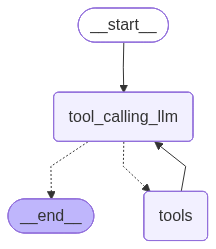

In [20]:
from IPython.display import Image, display


# Get graph visualization
display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
SYSTEM_PROMPT = """
You are a stock investment assistant.
Your task is to help users analyze stock portfolios and provide insights.

You have tools for stock, allocation, portfolio, correlation, fundamentals, memory, explainability, QnA, SWOT, and web search.
Use tools only when the user asks for analysis/search actions. For greetings and small talk, respond directly without tools.

Important tool-call rule:
For portfolio-dependent tools, always pass BOTH keys exactly as:
{"portfolio": {"INFY.NS": 10, "RELIANCE.NS": 4}, "value": 65500}
If either is missing, call get_portfolio first.
""".strip()

while True:
    user_input = input("User: ").strip()
    if user_input.lower() in ["exit", "quit", "no"]:
        print("Assistant: Goodbye!")
        break

    print("User:", user_input)

    thread_id = str(uuid.uuid4())
    state = State(
        {
            "messages": [
                SystemMessage(content=SYSTEM_PROMPT),
                HumanMessage(content=user_input),
            ]
        }
    )

    result = await graph.ainvoke(
        state,
        config={"configurable": {"thread_id": thread_id}},
    )

    interrupts = result.get("__interrupt__", [])
    if interrupts:
        prompt_to_human = interrupts[0].value
        print(f"HITL: {prompt_to_human}")
        decision = input("Your decision: ").strip()
        print(f"Your decision: {decision}")

        result = await graph.ainvoke(
            Command(resume=decision),
            config={"configurable": {"thread_id": thread_id}},
        )

    messages = result.get("messages", [])
    if messages:
        # Print the latest non-empty assistant content.
        bot_text = ""
        for msg in reversed(messages):
            content = getattr(msg, "content", "")
            if str(content).strip():
                bot_text = str(content)
                break
        if bot_text:
            print(f"Bot: {bot_text}\n")

User: Hi
Bot: Hello! How can I assist you today?

User: I need a full stock analysis of the TCS.NS including the history
Bot: The analysis of TCS.NS indicates the following:

1. **Technical Analysis**:
   - EMA50 is above EMA200, indicating a primary uptrend.
   - RSI is below 50, suggesting bearish momentum.
   - MACD histogram is negative, showing weakening momentum.
   - Volume-Price Trend (VPT) is falling, indicating negative volume-price flow.
   - Accumulation Distribution Line (ADL) is falling, reflecting distribution behavior.
   - Overall momentum is negative with dampened volume-adjusted momentum.

2. **Risk Analysis**:
   - Low volatility with compressed price variability.
   - Shallow drawdowns with historical downside contained.

3. **Fundamental Analysis**:
   - ROE (Return on Equity) is 0.4588.
   - PE (Price-to-Earnings) ratio is 17.63.
   - Revenue growth and ALTMAN Z score are not available.
   - Gross & EBIT margins are declining, indicating margin pressure.
   - Rev